# Problem 1 — Volume Estimation for $A_n$ and $B_n$

**Group 6 — MATH4010 Final Project**

This notebook contains the exact calculations, visualizations, Monte Carlo estimates, and extra method comparisons for Question 1.

In [1]:
# ============================================================
# Question 1: Monte Carlo Estimation for A_n and B_n
# ============================================================
#
# A_n = {x in R^n : ||x - (1/2)1||_2 <= 1/2}
# B_n = {x in R^n : ||x||_2 <= 1}
#
# A_n is a ball centered at (1/2,...,1/2) with radius 1/2.
# B_n is the unit ball centered at the origin.
#
# This code covers:
# 1.a: A_2 and B_2
# 1.b: A_3 and B_3
# 1.c: A_n and B_n, especially A_100 and B_100
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma, gammaln
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# ============================================================
# Helper Function 1: Exact volume of an n-dimensional ball
# ============================================================
#
# Formula:
# Volume of n-ball with radius r:
#
# V_n(r) = pi^(n/2) / Gamma(n/2 + 1) * r^n
#
# For B_n: r = 1
# For A_n: r = 1/2
# ============================================================


def exact_n_ball_volume(n, r=1.0):
    """
    Compute the exact volume of an n-dimensional ball with radius r.

    Parameters
    ----------
    n : int
        Dimension.
    r : float
        Radius of the n-dimensional ball.

    Returns
    -------
    float
        Exact volume.
    """
    return (np.pi ** (n / 2)) / gamma(n / 2 + 1) * (r**n)


# ============================================================
# Helper Function 2: Log-volume of an n-dimensional ball
# ============================================================
#
# In high dimensions, normal volume computation may underflow.
# So for n = 100, it is safer to compute log(volume).
#
# log V_n(r) = (n/2)log(pi) - log Gamma(n/2 + 1) + n log(r)
# ============================================================


def log_exact_n_ball_volume(n, r=1.0):
    """
    Compute the log-volume of an n-dimensional ball with radius r.

    This is more numerically stable for high dimensions.
    """
    return (n / 2) * np.log(np.pi) - gammaln(n / 2 + 1) + n * np.log(r)


# ============================================================
# Helper Function 3: Monte Carlo estimation for A_n
# ============================================================
#
# A_n is inside the unit box [0,1]^n.
#
# Sampling region:
# X_i ~ Uniform([0,1]^n)
#
# A point is inside A_n if:
# ||X_i - (1/2,...,1/2)||_2 <= 1/2
#
# Since volume of [0,1]^n is 1, the estimator is:
#
# Vol(A_n) ≈ (# inside A_n) / N
# ============================================================


def monte_carlo_A(n, N, seed=42):
    """
    Estimate volume of A_n using naive Monte Carlo rejection sampling.

    Parameters
    ----------
    n : int
        Dimension.
    N : int
        Number of random samples.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    estimate : float
        Monte Carlo volume estimate.
    inside_count : int
        Number of points inside A_n.
    acceptance_rate : float
        Proportion of sampled points inside A_n.
    """
    np.random.seed(seed)

    # Generate N random points uniformly from [0,1]^n
    X = np.random.uniform(0, 1, size=(N, n))

    # Center of A_n is (1/2,...,1/2)
    center = np.full(n, 0.5)

    # Compute Euclidean distance from each point to the center
    distances = np.linalg.norm(X - center, axis=1)

    # Check whether each point lies inside A_n
    inside = distances <= 0.5

    # Count accepted points
    inside_count = np.sum(inside)

    # Since box volume is 1, estimate equals acceptance rate
    acceptance_rate = inside_count / N
    estimate = acceptance_rate

    return estimate, inside_count, acceptance_rate


# ============================================================
# Helper Function 4: Monte Carlo estimation for B_n
# ============================================================
#
# B_n is inside the box [-1,1]^n.
#
# Sampling region:
# X_i ~ Uniform([-1,1]^n)
#
# A point is inside B_n if:
# ||X_i||_2 <= 1
#
# Volume of [-1,1]^n is 2^n.
#
# Estimator:
#
# Vol(B_n) ≈ 2^n * (# inside B_n) / N
# ============================================================


def monte_carlo_B(n, N, seed=42):
    """
    Estimate volume of B_n using naive Monte Carlo rejection sampling.

    Parameters
    ----------
    n : int
        Dimension.
    N : int
        Number of random samples.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    estimate : float
        Monte Carlo volume estimate.
    inside_count : int
        Number of points inside B_n.
    acceptance_rate : float
        Proportion of sampled points inside B_n.
    """
    np.random.seed(seed)

    # Generate N random points uniformly from [-1,1]^n
    X = np.random.uniform(-1, 1, size=(N, n))

    # Compute Euclidean norm of each point
    distances = np.linalg.norm(X, axis=1)

    # Check whether each point lies inside B_n
    inside = distances <= 1

    # Count accepted points
    inside_count = np.sum(inside)

    # Volume of bounding box [-1,1]^n
    box_volume = 2**n

    # Monte Carlo estimate
    acceptance_rate = inside_count / N
    estimate = box_volume * acceptance_rate

    return estimate, inside_count, acceptance_rate


# ============================================================
# Helper Function 5: Error metrics
# ============================================================


def compute_errors(estimate, exact):
    """
    Compute absolute error and relative error.

    Absolute Error = |estimate - exact|
    Relative Error = |estimate - exact| / exact
    """
    absolute_error = abs(estimate - exact)
    relative_error = absolute_error / exact if exact != 0 else np.nan

    return absolute_error, relative_error

## Question 1a

In [3]:
# ============================================================
# Part 1.a: Exact areas of A_2 and B_2
# ============================================================

exact_A2 = exact_n_ball_volume(n=2, r=0.5)
exact_B2 = exact_n_ball_volume(n=2, r=1.0)

print("Exact Area of A_2:", exact_A2)
print("Exact Area of B_2:", exact_B2)

Exact Area of A_2: 0.7853981633974483
Exact Area of B_2: 3.141592653589793


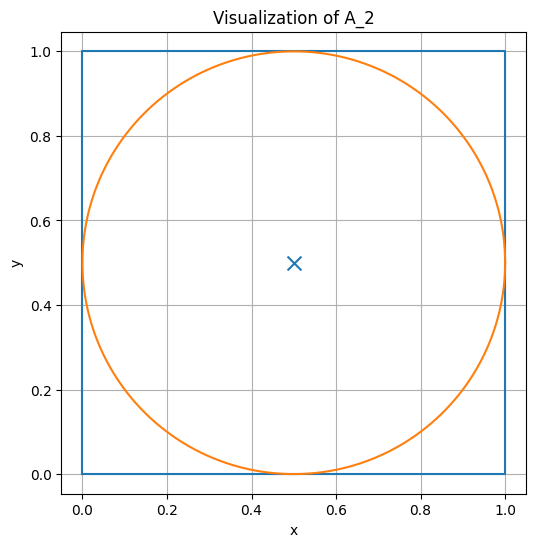

In [4]:
# ============================================================
# Part 1.a: Visualize A_2
# ============================================================
#
# A_2 is a circle centered at (0.5, 0.5) with radius 0.5.
# It is inscribed inside the unit square [0,1]^2.
# ============================================================

theta = np.linspace(0, 2 * np.pi, 400)

# Circle boundary for A_2
x_A2 = 0.5 + 0.5 * np.cos(theta)
y_A2 = 0.5 + 0.5 * np.sin(theta)

plt.figure(figsize=(6, 6))

# Draw unit square
plt.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], label="Unit Box [0,1]^2")

# Draw A_2 circle
plt.plot(x_A2, y_A2, label="A_2: center=(0.5,0.5), radius=0.5")

# Draw center
plt.scatter([0.5], [0.5], marker="x", s=100, label="Center of A_2")

plt.title("Visualization of A_2")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)


plt.show()

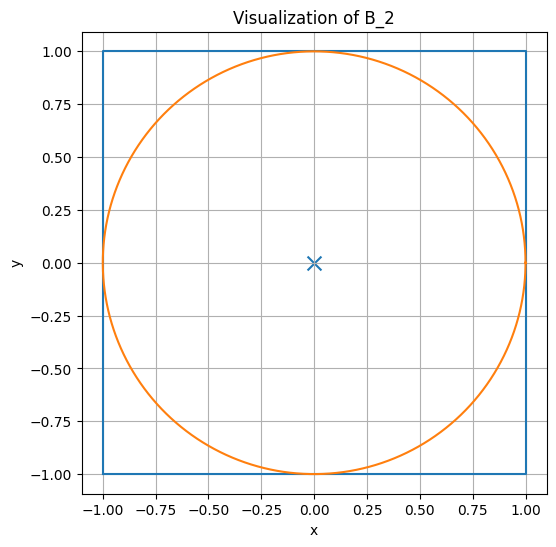

In [5]:
# ============================================================
# Part 1.a: Visualize B_2
# ============================================================
#
# B_2 is a unit circle centered at (0,0) with radius 1.
# It is inside the square [-1,1]^2.
# ============================================================

theta = np.linspace(0, 2 * np.pi, 400)

# Circle boundary for B_2
x_B2 = np.cos(theta)
y_B2 = np.sin(theta)

plt.figure(figsize=(6, 6))

# Draw bounding square [-1,1]^2
plt.plot([-1, 1, 1, -1, -1], [-1, -1, 1, 1, -1], label="Bounding Box [-1,1]^2")

# Draw B_2 circle
plt.plot(x_B2, y_B2, label="B_2: center=(0,0), radius=1")

# Draw center
plt.scatter([0], [0], marker="x", s=100, label="Center of B_2")

plt.title("Visualization of B_2")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)

plt.show()

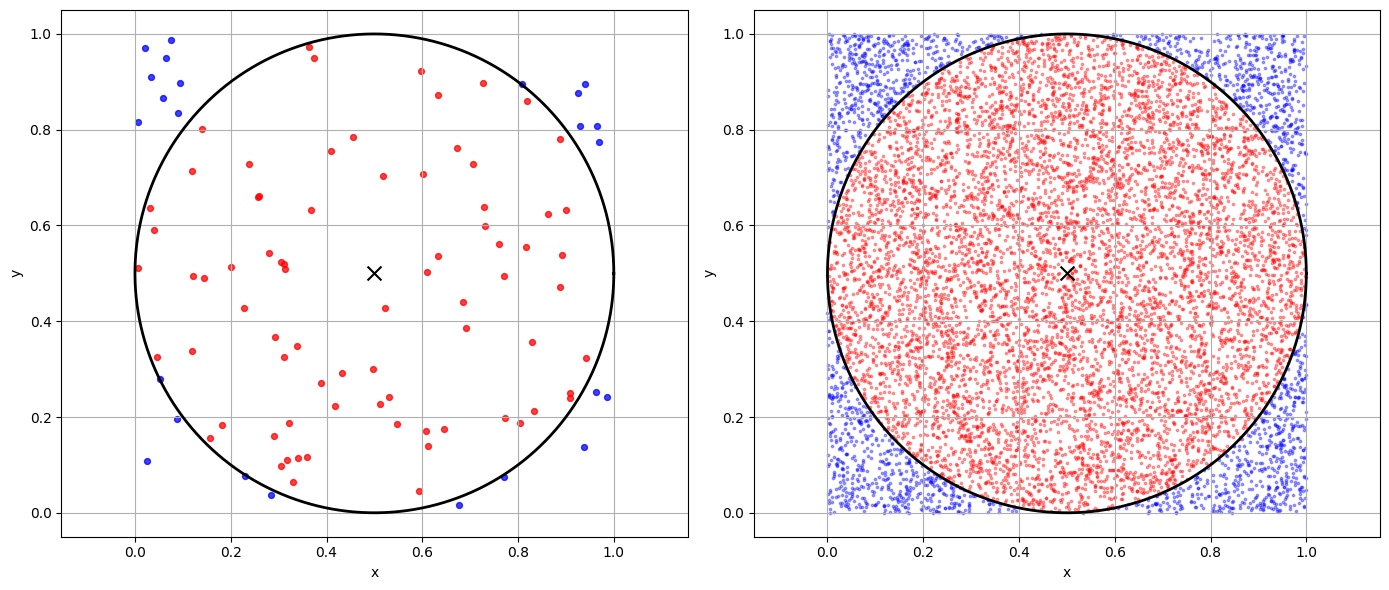

In [6]:
# ============================================================
# Part 1.a: Monte Carlo Visualization for A_2
# ============================================================
#
# Red points: inside A_2
# Blue points: outside A_2 but inside [0,1]^2
#
# We visualize two sample sizes:
# N = 100    : small sample size
# N = 10000  : large sample size
# ============================================================

N_values = [100, 10000]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, N in zip(axes, N_values):

    np.random.seed(42)

    # Sample points from [0,1]^2
    X = np.random.uniform(0, 1, size=(N, 2))

    # Check whether each point is inside A_2
    center_A2 = np.array([0.5, 0.5])
    distances = np.linalg.norm(X - center_A2, axis=1)
    inside = distances <= 0.5

    # Separate inside and outside points
    inside_points = X[inside]
    outside_points = X[~inside]

    # Use smaller point size for large N so the plot is still clear
    if N == 100:
        point_size = 18
        point_alpha = 0.75
    else:
        point_size = 3
        point_alpha = 0.35

    # Plot outside points
    ax.scatter(
        outside_points[:, 0],
        outside_points[:, 1],
        s=point_size,
        alpha=point_alpha,
        color="blue",
        label="Outside A_2",
    )

    # Plot inside points
    ax.scatter(
        inside_points[:, 0],
        inside_points[:, 1],
        s=point_size,
        alpha=point_alpha,
        color="red",
        label="Inside A_2",
    )

    # Plot boundary of A_2
    ax.plot(x_A2, y_A2, linewidth=2, color="black", label="Boundary of A_2")

    # Plot center
    ax.scatter([0.5], [0.5], marker="x", s=100, color="black", label="Center")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.axis("equal")
    ax.grid(True)


plt.tight_layout()
plt.show()

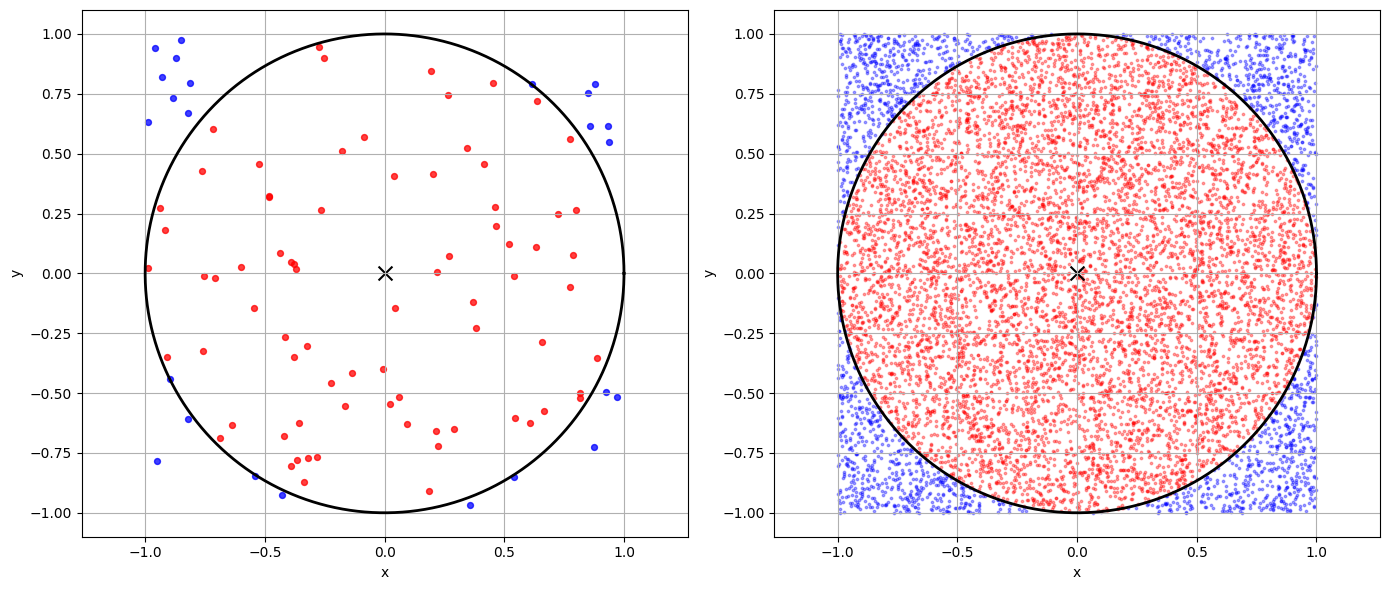

In [7]:
# ============================================================
# Part 1.a: Monte Carlo Visualization for B_2
# ============================================================
#
# Red points: inside B_2
# Blue points: outside B_2 but inside [-1,1]^2
#
# We visualize two sample sizes:
# N = 100    : small sample size
# N = 10000  : large sample size
# ============================================================

N_values = [100, 10000]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, N in zip(axes, N_values):

    np.random.seed(42)

    # Sample points from [-1,1]^2
    X = np.random.uniform(-1, 1, size=(N, 2))

    # Check whether each point is inside B_2
    distances = np.linalg.norm(X, axis=1)
    inside = distances <= 1

    # Separate inside and outside points
    inside_points = X[inside]
    outside_points = X[~inside]

    # Use smaller point size for large N so the plot is still clear
    if N == 100:
        point_size = 18
        point_alpha = 0.75
    else:
        point_size = 3
        point_alpha = 0.35

    # Plot outside points
    ax.scatter(
        outside_points[:, 0],
        outside_points[:, 1],
        s=point_size,
        alpha=point_alpha,
        color="blue",
        label="Outside B_2",
    )

    # Plot inside points
    ax.scatter(
        inside_points[:, 0],
        inside_points[:, 1],
        s=point_size,
        alpha=point_alpha,
        color="red",
        label="Inside B_2",
    )

    # Plot boundary
    ax.plot(x_B2, y_B2, linewidth=2, color="black", label="Boundary of B_2")

    # Plot center
    ax.scatter([0], [0], marker="x", s=100, color="black", label="Center")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.axis("equal")
    ax.grid(True)


plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# Part 1.a: Monte Carlo estimates for A_2 and B_2
# ============================================================
#
# Main method: Naive Monte Carlo rejection sampling
#
# We compare two sample sizes:
# N = 100    : small sample size
# N = 10000  : large sample size
# ============================================================

N_values = [100, 10000]

part_1a_mc_tables = {}

for N in N_values:

    # Estimate A_2
    estimate_A2, inside_A2, acc_A2 = monte_carlo_A(n=2, N=N, seed=42)
    abs_err_A2, rel_err_A2 = compute_errors(estimate_A2, exact_A2)

    # Estimate B_2
    estimate_B2, inside_B2, acc_B2 = monte_carlo_B(n=2, N=N, seed=42)
    abs_err_B2, rel_err_B2 = compute_errors(estimate_B2, exact_B2)

    # Create table for current N
    table = pd.DataFrame(
        {
            "Shape": ["A_2", "B_2"],
            "Exact Value": [exact_A2, exact_B2],
            "Monte Carlo Estimate": [estimate_A2, estimate_B2],
            "Number of Points Inside": [inside_A2, inside_B2],
            "Acceptance Rate": [acc_A2, acc_B2],
            "Absolute Error": [abs_err_A2, abs_err_B2],
            "Relative Error": [rel_err_A2, rel_err_B2],
        }
    )

    part_1a_mc_tables[N] = table

    print(f"========== Part 1.a Results for N = {N} ==========")
    display(table)

========== Part 1.a Results for N = 100 ==========


,Shape,Exact Value,Monte Carlo Estimate,Number of Points Inside,Acceptance Rate,Absolute Error,Relative Error
0,A_2,0.785398,0.76,76,0.76,0.025398,0.032338
1,B_2,3.141593,3.04,76,0.76,0.101593,0.032338


========== Part 1.a Results for N = 10000 ==========


,Shape,Exact Value,Monte Carlo Estimate,Number of Points Inside,Acceptance Rate,Absolute Error,Relative Error
0,A_2,0.785398,0.7886,7886,0.7886,0.003202,0.004077
1,B_2,3.141593,3.1544,7886,0.7886,0.012807,0.004077


In [9]:
# ============================================================
# Part 1.a: Formatted Monte Carlo tables
# ============================================================

for N in N_values:

    formatted_table = part_1a_mc_tables[N].copy()

    formatted_table["Exact Value"] = formatted_table["Exact Value"].map(
        lambda x: f"{x:.6f}"
    )
    formatted_table["Monte Carlo Estimate"] = formatted_table[
        "Monte Carlo Estimate"
    ].map(lambda x: f"{x:.6f}")
    formatted_table["Acceptance Rate"] = formatted_table["Acceptance Rate"].map(
        lambda x: f"{x:.4%}"
    )
    formatted_table["Absolute Error"] = formatted_table["Absolute Error"].map(
        lambda x: f"{x:.6f}"
    )
    formatted_table["Relative Error"] = formatted_table["Relative Error"].map(
        lambda x: f"{x:.4%}"
    )
    formatted_table["Number of Points Inside"] = formatted_table[
        "Number of Points Inside"
    ].map(lambda x: f"{int(x):,}")

    print(f"========== Formatted Part 1.a Results for N = {N} ==========")
    display(formatted_table)

========== Formatted Part 1.a Results for N = 100 ==========


,Shape,Exact Value,Monte Carlo Estimate,Number of Points Inside,Acceptance Rate,Absolute Error,Relative Error
0,A_2,0.785398,0.760000,76,76.0000%,0.025398,3.2338%
1,B_2,3.141593,3.040000,76,76.0000%,0.101593,3.2338%


========== Formatted Part 1.a Results for N = 10000 ==========


,Shape,Exact Value,Monte Carlo Estimate,Number of Points Inside,Acceptance Rate,Absolute Error,Relative Error
0,A_2,0.785398,0.788600,"7,886",78.8600%,0.003202,0.4077%
1,B_2,3.141593,3.154400,"7,886",78.8600%,0.012807,0.4077%


## Question 1b

In [10]:
# ============================================================
# Part 1.b: Exact volumes of A_3 and B_3
# ============================================================

exact_A3 = exact_n_ball_volume(n=3, r=0.5)
exact_B3 = exact_n_ball_volume(n=3, r=1.0)

print("Exact Volume of A_3:", exact_A3)
print("Exact Volume of B_3:", exact_B3)

Exact Volume of A_3: 0.5235987755982989
Exact Volume of B_3: 4.188790204786391


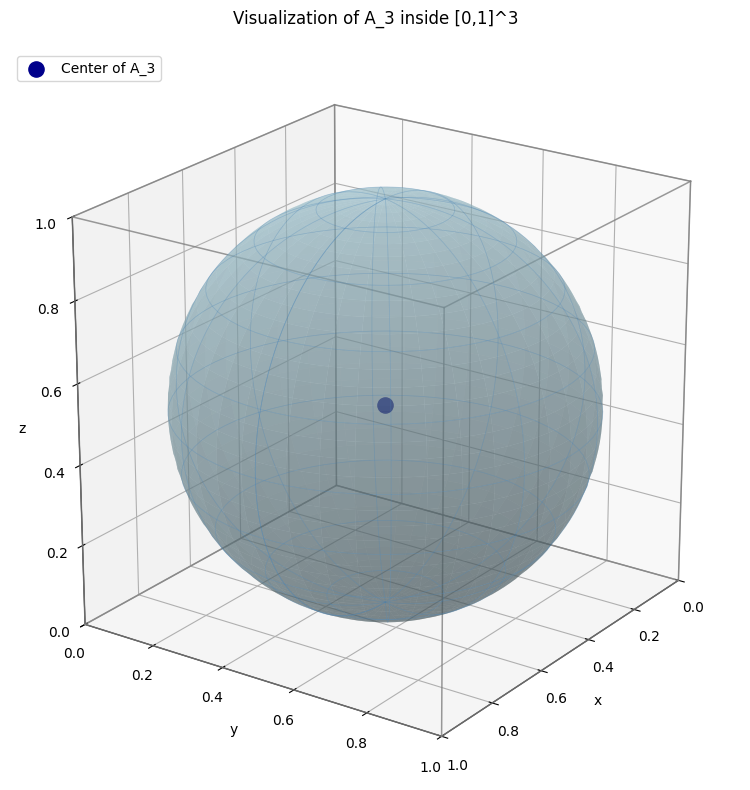

In [11]:
# ============================================================
# Part 1.b: Visualize A_3
# ============================================================
#
# A_3 is a sphere centered at (0.5,0.5,0.5)
# with radius 0.5, inside the cube [0,1]^3.
# ===========================================================


import numpy as np

import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D


def draw_cube_edges(ax, lower, upper):
    """

    Draw the edges of a cube from lower bound to upper bound.

    """

    x0, y0, z0 = lower

    x1, y1, z1 = upper

    corners = np.array(
        [
            [x0, y0, z0],
            [x1, y0, z0],
            [x1, y1, z0],
            [x0, y1, z0],
            [x0, y0, z1],
            [x1, y0, z1],
            [x1, y1, z1],
            [x0, y1, z1],
        ]
    )

    edges = [
        (0, 1),
        (1, 2),
        (2, 3),
        (3, 0),
        (4, 5),
        (5, 6),
        (6, 7),
        (7, 4),
        (0, 4),
        (1, 5),
        (2, 6),
        (3, 7),
    ]

    for i, j in edges:

        ax.plot(
            [corners[i, 0], corners[j, 0]],
            [corners[i, 1], corners[j, 1]],
            [corners[i, 2], corners[j, 2]],
            color="gray",
            linewidth=1.1,
            alpha=0.8,
        )


center = np.array([0.5, 0.5, 0.5])

radius = 0.5

u = np.linspace(0, 2 * np.pi, 80)

v = np.linspace(0, np.pi, 80)

x = center[0] + radius * np.outer(np.cos(u), np.sin(v))

y = center[1] + radius * np.outer(np.sin(u), np.sin(v))

z = center[2] + radius * np.outer(np.ones_like(u), np.cos(v))

fig = plt.figure(figsize=(9, 8))

ax = fig.add_subplot(111, projection="3d")

draw_cube_edges(ax, lower=(0, 0, 0), upper=(1, 1, 1))

ax.plot_surface(x, y, z, color="lightblue", alpha=0.45, linewidth=0, antialiased=True)

ax.plot_wireframe(
    x, y, z, color="steelblue", rstride=8, cstride=8, linewidth=0.5, alpha=0.35
)

ax.scatter(
    [center[0]],
    [center[1]],
    [center[2]],
    color="darkblue",
    s=120,
    marker="o",
    label="Center of A_3",
)

ax.set_title("Visualization of A_3 inside [0,1]^3", pad=18)

ax.set_xlabel("x")

ax.set_ylabel("y")

ax.set_zlabel("z")

ax.set_xlim(0, 1)

ax.set_ylim(0, 1)

ax.set_zlim(0, 1)

ax.set_box_aspect([1, 1, 1])

ax.view_init(elev=22, azim=35)

ax.legend(loc="upper left")

plt.tight_layout()

plt.show()

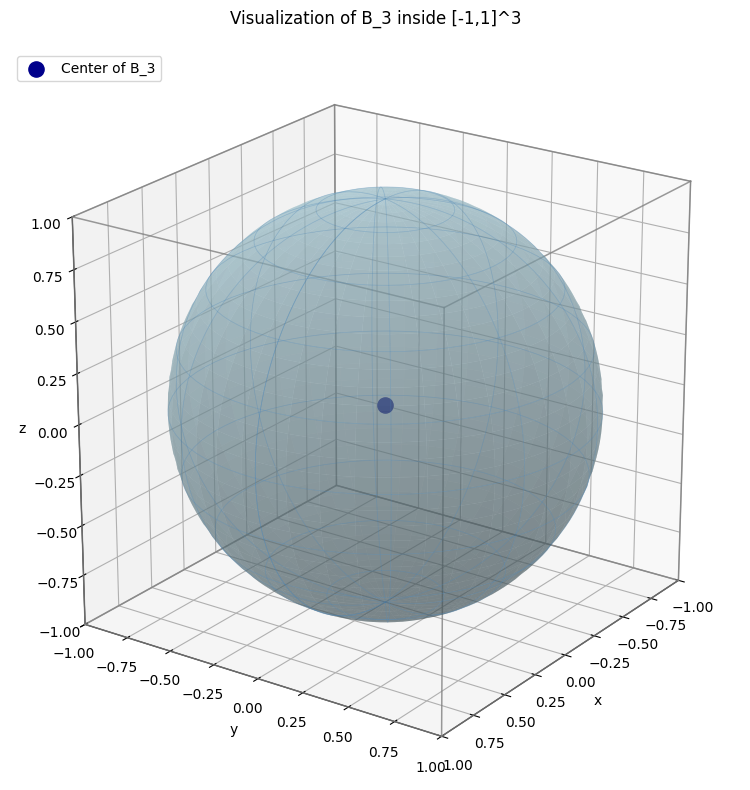

In [12]:
# ============================================================
# Part 1.b: Visualize B_3
# ============================================================
#
# B_3 is the unit sphere centered at (0,0,0)
# with radius 1, inside the cube [-1,1]^3.
# ============================================================

center = np.array([0, 0, 0])

radius = 1.0

u = np.linspace(0, 2 * np.pi, 80)

v = np.linspace(0, np.pi, 80)

x = center[0] + radius * np.outer(np.cos(u), np.sin(v))

y = center[1] + radius * np.outer(np.sin(u), np.sin(v))

z = center[2] + radius * np.outer(np.ones_like(u), np.cos(v))

fig = plt.figure(figsize=(9, 8))

ax = fig.add_subplot(111, projection="3d")

draw_cube_edges(ax, lower=(-1, -1, -1), upper=(1, 1, 1))

ax.plot_surface(x, y, z, color="lightblue", alpha=0.45, linewidth=0, antialiased=True)

ax.plot_wireframe(
    x, y, z, color="steelblue", rstride=8, cstride=8, linewidth=0.5, alpha=0.35
)

ax.scatter(
    [center[0]],
    [center[1]],
    [center[2]],
    color="darkblue",
    s=120,
    marker="o",
    label="Center of B_3",
)

ax.set_title("Visualization of B_3 inside [-1,1]^3", pad=18)

ax.set_xlabel("x")

ax.set_ylabel("y")

ax.set_zlabel("z")

ax.set_xlim(-1, 1)

ax.set_ylim(-1, 1)

ax.set_zlim(-1, 1)

ax.set_box_aspect([1, 1, 1])

ax.view_init(elev=22, azim=35)

ax.legend(loc="upper left")

plt.tight_layout()

plt.show()

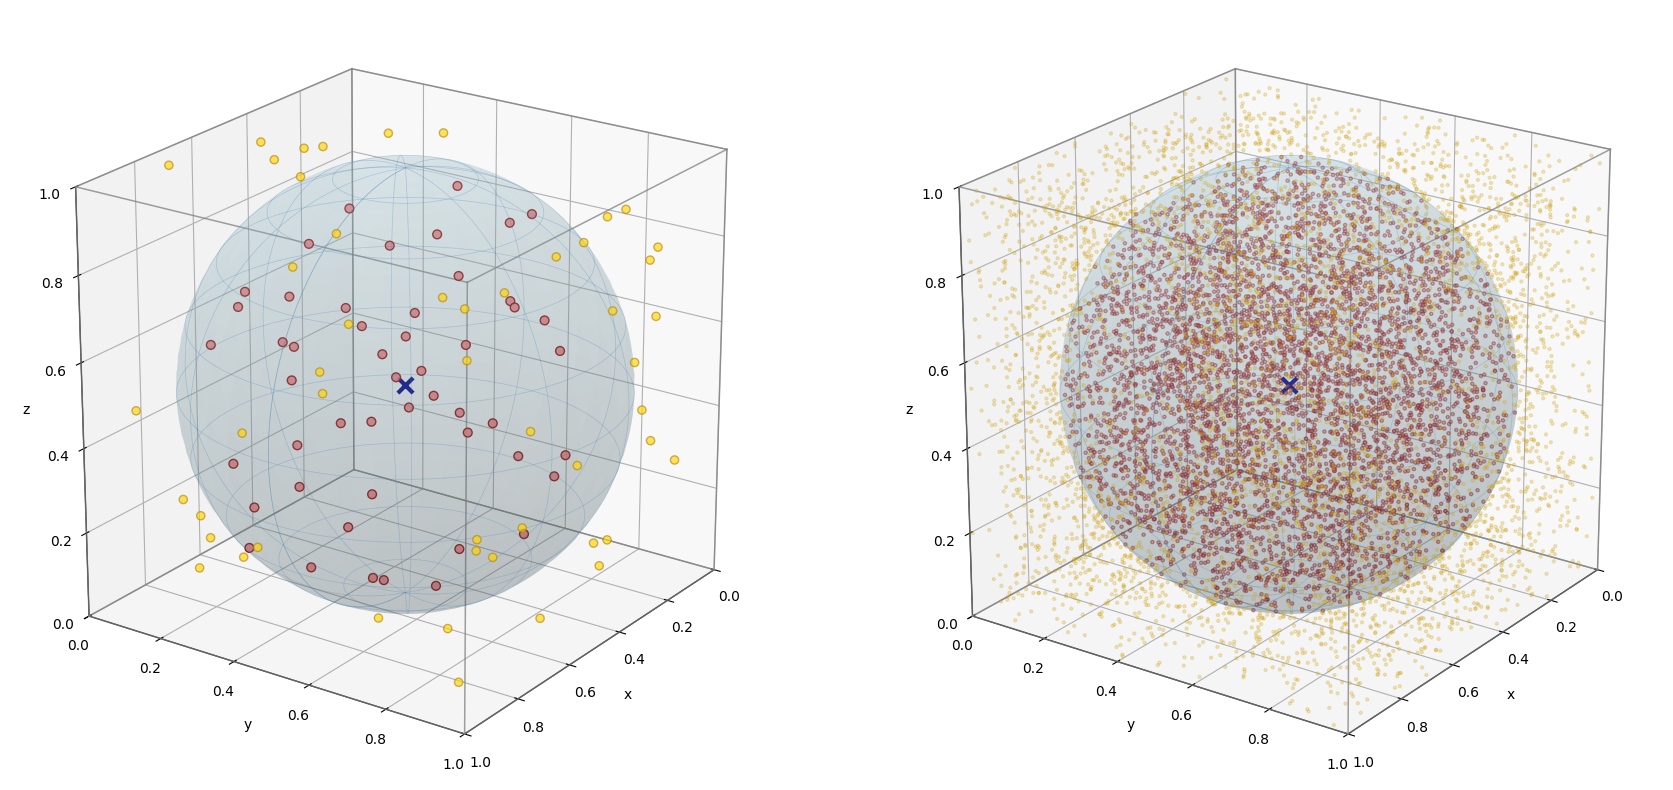

In [13]:
# ============================================================
# Part 1.b: Monte Carlo Visualization for A_3
# ============================================================
#
# Red points: inside A_3
# Yellow points: outside A_3 but inside [0,1]^3
# Light blue transparent sphere: boundary of A_3
#
# We visualize two sample sizes:
# N = 100    : small sample size
# N = 10000  : large sample size
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


def draw_cube_edges(ax, lower, upper):
    """
    Draw the edges of a cube from lower bound to upper bound.
    """

    x0, y0, z0 = lower
    x1, y1, z1 = upper

    corners = np.array(
        [
            [x0, y0, z0],
            [x1, y0, z0],
            [x1, y1, z0],
            [x0, y1, z0],
            [x0, y0, z1],
            [x1, y0, z1],
            [x1, y1, z1],
            [x0, y1, z1],
        ]
    )

    edges = [
        (0, 1),
        (1, 2),
        (2, 3),
        (3, 0),
        (4, 5),
        (5, 6),
        (6, 7),
        (7, 4),
        (0, 4),
        (1, 5),
        (2, 6),
        (3, 7),
    ]

    for i, j in edges:
        ax.plot(
            [corners[i, 0], corners[j, 0]],
            [corners[i, 1], corners[j, 1]],
            [corners[i, 2], corners[j, 2]],
            color="gray",
            linewidth=1.1,
            alpha=0.75,
        )


N_values = [100, 10000]

# Define A_3
center_A3 = np.array([0.5, 0.5, 0.5])
radius_A3 = 0.5

# Create sphere surface for A_3
u = np.linspace(0, 2 * np.pi, 80)
v = np.linspace(0, np.pi, 80)

sphere_x = center_A3[0] + radius_A3 * np.outer(np.cos(u), np.sin(v))
sphere_y = center_A3[1] + radius_A3 * np.outer(np.sin(u), np.sin(v))
sphere_z = center_A3[2] + radius_A3 * np.outer(np.ones_like(u), np.cos(v))

fig = plt.figure(figsize=(18, 8))

for i, N in enumerate(N_values):

    np.random.seed(42)

    # Sample points from [0,1]^3
    X = np.random.uniform(0, 1, size=(N, 3))

    # Check whether each point is inside A_3
    distances = np.linalg.norm(X - center_A3, axis=1)
    inside = distances <= radius_A3

    # Separate inside and outside points
    inside_points = X[inside]
    outside_points = X[~inside]

    # Use smaller point size for large N so the plot is still clear
    if N == 100:
        outside_size = 35
        inside_size = 40
        outside_alpha = 0.65
        inside_alpha = 0.90
    else:
        outside_size = 4
        inside_size = 5
        outside_alpha = 0.25
        inside_alpha = 0.45

    ax = fig.add_subplot(1, 2, i + 1, projection="3d")

    # Draw bounding cube [0,1]^3
    draw_cube_edges(ax, lower=(0, 0, 0), upper=(1, 1, 1))

    # Plot outside points first so inside points remain more visible
    ax.scatter(
        outside_points[:, 0],
        outside_points[:, 1],
        outside_points[:, 2],
        color="gold",
        edgecolor="darkgoldenrod",
        s=outside_size,
        alpha=outside_alpha,
        label="Outside A_3",
    )

    # Plot inside points
    ax.scatter(
        inside_points[:, 0],
        inside_points[:, 1],
        inside_points[:, 2],
        color="lightcoral",
        edgecolor="darkred",
        s=inside_size,
        alpha=inside_alpha,
        label="Inside A_3",
    )

    # Plot transparent sphere surface
    ax.plot_surface(
        sphere_x,
        sphere_y,
        sphere_z,
        color="lightblue",
        alpha=0.18,
        linewidth=0,
        antialiased=True,
    )

    # Plot sphere wireframe
    ax.plot_wireframe(
        sphere_x,
        sphere_y,
        sphere_z,
        color="steelblue",
        rstride=8,
        cstride=8,
        linewidth=0.5,
        alpha=0.30,
    )

    # Plot center
    ax.scatter(
        [center_A3[0]],
        [center_A3[1]],
        [center_A3[2]],
        color="darkblue",
        s=120,
        marker="x",
        linewidths=3,
        label="Center of A_3",
    )

    # Titles and labels

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    # Axis limits
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_zlim(0, 1)

    # Equal aspect ratio
    ax.set_box_aspect([1, 1, 1])

    # Better viewing angle
    ax.view_init(elev=22, azim=35)


plt.tight_layout()
plt.show()

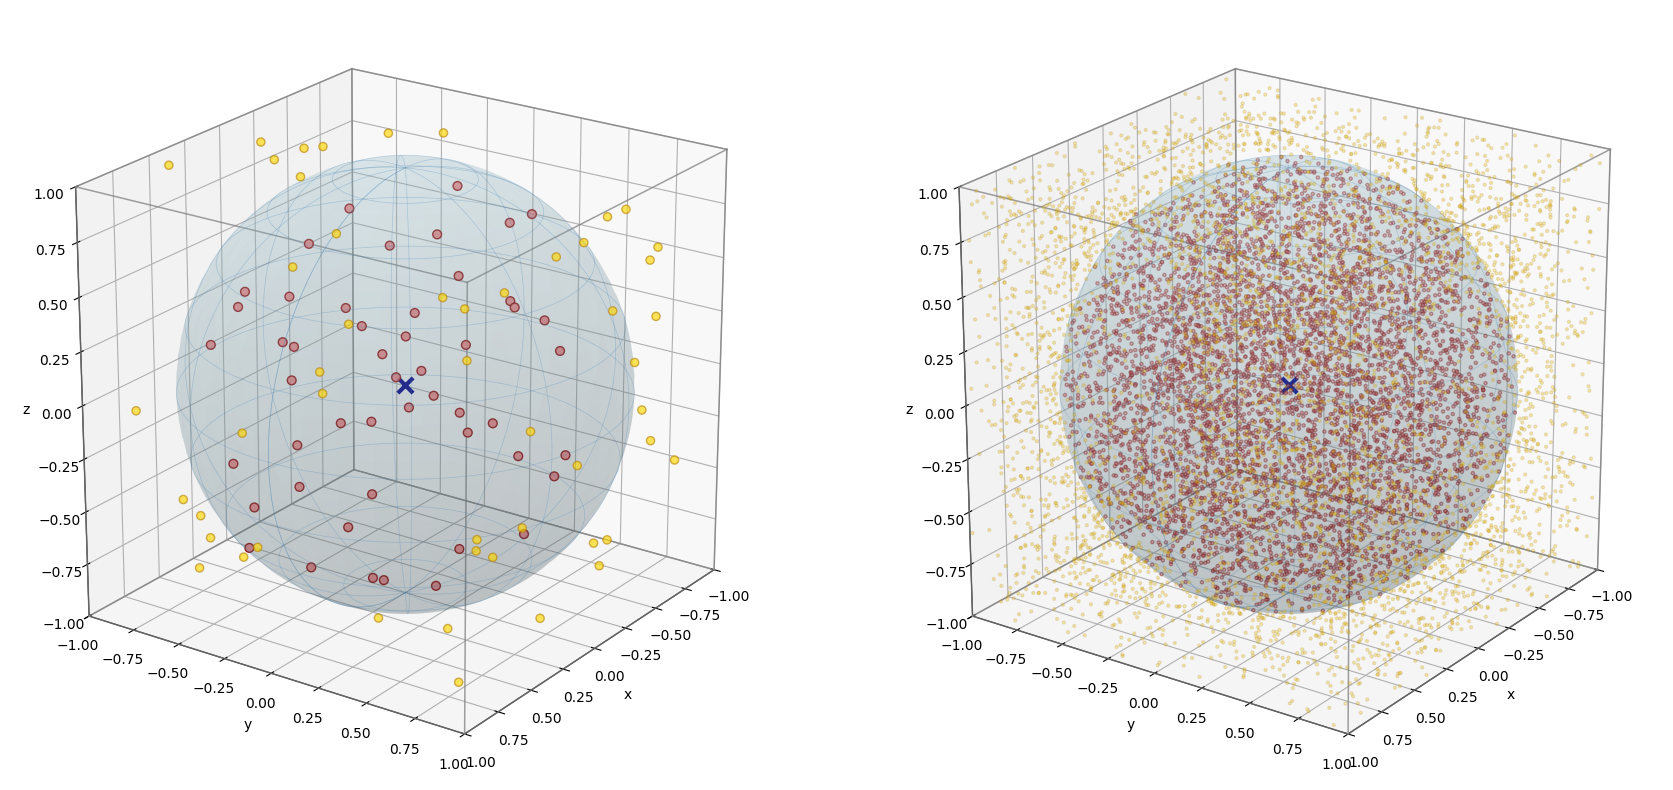

In [14]:
# ============================================================
# Part 1.b: Monte Carlo Visualization for B_3
# ============================================================
#
# Red points: inside B_3
# Yellow points: outside B_3 but inside [-1,1]^3
# Light blue transparent sphere: boundary of B_3
#
# We visualize two sample sizes:
# N = 100    : small sample size
# N = 10000  : large sample size
# ============================================================


def draw_cube_edges(ax, lower, upper):
    """
    Draw the edges of a cube from lower bound to upper bound.
    """

    x0, y0, z0 = lower
    x1, y1, z1 = upper

    corners = np.array(
        [
            [x0, y0, z0],
            [x1, y0, z0],
            [x1, y1, z0],
            [x0, y1, z0],
            [x0, y0, z1],
            [x1, y0, z1],
            [x1, y1, z1],
            [x0, y1, z1],
        ]
    )

    edges = [
        (0, 1),
        (1, 2),
        (2, 3),
        (3, 0),
        (4, 5),
        (5, 6),
        (6, 7),
        (7, 4),
        (0, 4),
        (1, 5),
        (2, 6),
        (3, 7),
    ]

    for i, j in edges:
        ax.plot(
            [corners[i, 0], corners[j, 0]],
            [corners[i, 1], corners[j, 1]],
            [corners[i, 2], corners[j, 2]],
            color="gray",
            linewidth=1.1,
            alpha=0.75,
        )


N_values = [100, 10000]

# Define B_3
center_B3 = np.array([0.0, 0.0, 0.0])
radius_B3 = 1.0

# Create sphere surface for B_3
u = np.linspace(0, 2 * np.pi, 80)
v = np.linspace(0, np.pi, 80)

sphere_x = center_B3[0] + radius_B3 * np.outer(np.cos(u), np.sin(v))
sphere_y = center_B3[1] + radius_B3 * np.outer(np.sin(u), np.sin(v))
sphere_z = center_B3[2] + radius_B3 * np.outer(np.ones_like(u), np.cos(v))

fig = plt.figure(figsize=(18, 8))

for i, N in enumerate(N_values):

    np.random.seed(42)

    # Sample points from [-1,1]^3
    X = np.random.uniform(-1, 1, size=(N, 3))

    # Check whether each point is inside B_3
    distances = np.linalg.norm(X - center_B3, axis=1)
    inside = distances <= radius_B3

    # Separate inside and outside points
    inside_points = X[inside]
    outside_points = X[~inside]

    # Use smaller point size for large N so the plot is still clear
    if N == 100:
        outside_size = 35
        inside_size = 40
        outside_alpha = 0.65
        inside_alpha = 0.90
    else:
        outside_size = 4
        inside_size = 5
        outside_alpha = 0.25
        inside_alpha = 0.45

    ax = fig.add_subplot(1, 2, i + 1, projection="3d")

    # Draw bounding cube [-1,1]^3
    draw_cube_edges(ax, lower=(-1, -1, -1), upper=(1, 1, 1))

    # Plot outside points first
    ax.scatter(
        outside_points[:, 0],
        outside_points[:, 1],
        outside_points[:, 2],
        color="gold",
        edgecolor="darkgoldenrod",
        s=outside_size,
        alpha=outside_alpha,
        label="Outside B_3",
    )

    # Plot inside points
    ax.scatter(
        inside_points[:, 0],
        inside_points[:, 1],
        inside_points[:, 2],
        color="lightcoral",
        edgecolor="darkred",
        s=inside_size,
        alpha=inside_alpha,
        label="Inside B_3",
    )

    # Plot transparent sphere surface
    ax.plot_surface(
        sphere_x,
        sphere_y,
        sphere_z,
        color="lightblue",
        alpha=0.18,
        linewidth=0,
        antialiased=True,
    )

    # Plot sphere wireframe
    ax.plot_wireframe(
        sphere_x,
        sphere_y,
        sphere_z,
        color="steelblue",
        rstride=8,
        cstride=8,
        linewidth=0.5,
        alpha=0.30,
    )

    # Plot center
    ax.scatter(
        [center_B3[0]],
        [center_B3[1]],
        [center_B3[2]],
        color="darkblue",
        s=120,
        marker="x",
        linewidths=3,
        label="Center of B_3",
    )

    # Titles and labels

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    # Axis limits
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)

    # Equal aspect ratio
    ax.set_box_aspect([1, 1, 1])

    # Better viewing angle
    ax.view_init(elev=22, azim=35)

    # Legend


plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# Part 1.b: Monte Carlo estimates for A_3 and B_3
# ============================================================
#
# Main method: Naive Monte Carlo rejection sampling
#
# We compare two sample sizes:
# N = 100    : small sample size
# N = 10000  : large sample size
# ============================================================

N_values = [100, 10000]

part_1b_mc_tables = {}

for N in N_values:

    # Estimate A_3
    estimate_A3, inside_A3, acc_A3 = monte_carlo_A(n=3, N=N, seed=42)
    abs_err_A3, rel_err_A3 = compute_errors(estimate_A3, exact_A3)

    # Estimate B_3
    estimate_B3, inside_B3, acc_B3 = monte_carlo_B(n=3, N=N, seed=42)
    abs_err_B3, rel_err_B3 = compute_errors(estimate_B3, exact_B3)

    # Create table for current N
    table = pd.DataFrame(
        {
            "Shape": ["A_3", "B_3"],
            "Exact Value": [exact_A3, exact_B3],
            "Monte Carlo Estimate": [estimate_A3, estimate_B3],
            "Number of Points Inside": [inside_A3, inside_B3],
            "Acceptance Rate": [acc_A3, acc_B3],
            "Absolute Error": [abs_err_A3, abs_err_B3],
            "Relative Error": [rel_err_A3, rel_err_B3],
        }
    )

    part_1b_mc_tables[N] = table

    print(f"========== Part 1.b Results for N = {N} ==========")
    display(table)

========== Part 1.b Results for N = 100 ==========


,Shape,Exact Value,Monte Carlo Estimate,Number of Points Inside,Acceptance Rate,Absolute Error,Relative Error
0,A_3,0.523599,0.5,50,0.5,0.023599,0.04507
1,B_3,4.188790,4.0,50,0.5,0.188790,0.04507


========== Part 1.b Results for N = 10000 ==========


,Shape,Exact Value,Monte Carlo Estimate,Number of Points Inside,Acceptance Rate,Absolute Error,Relative Error
0,A_3,0.523599,0.5304,5304,0.5304,0.006801,0.012989
1,B_3,4.188790,4.2432,5304,0.5304,0.054410,0.012989


In [16]:
# ============================================================
# Part 1.b: Formatted Monte Carlo tables
# ============================================================

for N in N_values:

    formatted_table = part_1b_mc_tables[N].copy()

    formatted_table["Exact Value"] = formatted_table["Exact Value"].map(
        lambda x: f"{x:.6f}"
    )
    formatted_table["Monte Carlo Estimate"] = formatted_table[
        "Monte Carlo Estimate"
    ].map(lambda x: f"{x:.6f}")
    formatted_table["Acceptance Rate"] = formatted_table["Acceptance Rate"].map(
        lambda x: f"{x:.4%}"
    )
    formatted_table["Absolute Error"] = formatted_table["Absolute Error"].map(
        lambda x: f"{x:.6f}"
    )
    formatted_table["Relative Error"] = formatted_table["Relative Error"].map(
        lambda x: f"{x:.4%}"
    )
    formatted_table["Number of Points Inside"] = formatted_table[
        "Number of Points Inside"
    ].map(lambda x: f"{int(x):,}")

    print(f"========== Formatted Part 1.b Results for N = {N} ==========")
    display(formatted_table)

========== Formatted Part 1.b Results for N = 100 ==========


,Shape,Exact Value,Monte Carlo Estimate,Number of Points Inside,Acceptance Rate,Absolute Error,Relative Error
0,A_3,0.523599,0.500000,50,50.0000%,0.023599,4.5070%
1,B_3,4.188790,4.000000,50,50.0000%,0.188790,4.5070%


========== Formatted Part 1.b Results for N = 10000 ==========


,Shape,Exact Value,Monte Carlo Estimate,Number of Points Inside,Acceptance Rate,Absolute Error,Relative Error
0,A_3,0.523599,0.530400,"5,304",53.0400%,0.006801,1.2989%
1,B_3,4.188790,4.243200,"5,304",53.0400%,0.054410,1.2989%


## Question 1c

In [17]:
# ============================================================
# Part 1.c: Exact volume formulas for A_n and B_n
# ============================================================


def exact_A_volume(n):
    """
    Exact volume of A_n.

    A_n has radius 1/2.
    """
    return exact_n_ball_volume(n=n, r=0.5)


def exact_B_volume(n):
    """
    Exact volume of B_n.

    B_n has radius 1.
    """
    return exact_n_ball_volume(n=n, r=1.0)


def log_exact_A_volume(n):
    """
    Log exact volume of A_n.
    Useful for high dimensions.
    """
    return log_exact_n_ball_volume(n=n, r=0.5)


def log_exact_B_volume(n):
    """
    Log exact volume of B_n.
    Useful for high dimensions.
    """
    return log_exact_n_ball_volume(n=n, r=1.0)

In [18]:
# ============================================================
# Part 1.c: Exact volumes for A_100 and B_100
# ============================================================

n = 100

exact_A100 = exact_A_volume(n)
exact_B100 = exact_B_volume(n)

log_exact_A100 = log_exact_A_volume(n)
log_exact_B100 = log_exact_B_volume(n)

print("========== Exact Volumes for n = 100 ==========")

print("\nB_100:")
print("Exact Volume:", exact_B100)
print("Log Exact Volume:", log_exact_B100)

print("\nA_100:")
print("Exact Volume:", exact_A100)
print("Log Exact Volume:", log_exact_A100)

========== Exact Volumes for n = 100 ==========

B_100:
Exact Volume: 2.368202101882829e-40
Log Exact Volume: -91.24127265930301

A_100:
Exact Volume: 1.8681820538375912e-70
Log Exact Volume: -160.55599071529753


In [19]:
# ============================================================
# Part 1.c: Naive Monte Carlo estimates for A_100 and B_100
# ============================================================
#
# Warning:
# In high dimensions, this method becomes extremely inefficient.
# Most sampled points from the bounding box will fall outside the ball.
#
# This is the curse of dimensionality.
#
# We compare two sample sizes:
# N = 100    : small sample size
# N = 10000  : large sample size
# ============================================================

N_values = [100, 10000]

part_1c_mc_tables = {}

for N in N_values:

    # Estimate A_100
    estimate_A100, inside_A100, acc_A100 = monte_carlo_A(n=100, N=N, seed=42)
    abs_err_A100, rel_err_A100 = compute_errors(estimate_A100, exact_A100)

    # Estimate B_100
    estimate_B100, inside_B100, acc_B100 = monte_carlo_B(n=100, N=N, seed=42)
    abs_err_B100, rel_err_B100 = compute_errors(estimate_B100, exact_B100)

    # Create table for current N
    table = pd.DataFrame(
        {
            "Shape": ["A_100", "B_100"],
            "Exact Value": [exact_A100, exact_B100],
            "Monte Carlo Estimate": [estimate_A100, estimate_B100],
            "Number of Points Inside": [inside_A100, inside_B100],
            "Acceptance Rate": [acc_A100, acc_B100],
            "Absolute Error": [abs_err_A100, abs_err_B100],
            "Relative Error": [rel_err_A100, rel_err_B100],
        }
    )

    part_1c_mc_tables[N] = table

    print(f"========== Part 1.c Monte Carlo Results for N = {N} ==========")
    display(table)

========== Part 1.c Monte Carlo Results for N = 100 ==========


,Shape,Exact Value,Monte Carlo Estimate,Number of Points Inside,Acceptance Rate,Absolute Error,Relative Error
0,A_100,1.868182e-70,0.0,0,0.0,1.868182e-70,1.0
1,B_100,2.368202e-40,0.0,0,0.0,2.368202e-40,1.0


========== Part 1.c Monte Carlo Results for N = 10000 ==========


,Shape,Exact Value,Monte Carlo Estimate,Number of Points Inside,Acceptance Rate,Absolute Error,Relative Error
0,A_100,1.868182e-70,0.0,0,0.0,1.868182e-70,1.0
1,B_100,2.368202e-40,0.0,0,0.0,2.368202e-40,1.0


In [20]:
# ============================================================
# Part 1.c: Formatted Monte Carlo tables
# ============================================================

for N in N_values:

    formatted_table = part_1c_mc_tables[N].copy()

    formatted_table["Exact Value"] = formatted_table["Exact Value"].map(
        lambda x: f"{x:.6e}"
    )
    formatted_table["Monte Carlo Estimate"] = formatted_table[
        "Monte Carlo Estimate"
    ].map(lambda x: f"{x:.6e}")
    formatted_table["Acceptance Rate"] = formatted_table["Acceptance Rate"].map(
        lambda x: f"{x:.6e}"
    )
    formatted_table["Absolute Error"] = formatted_table["Absolute Error"].map(
        lambda x: f"{x:.6e}"
    )
    formatted_table["Relative Error"] = formatted_table["Relative Error"].map(
        lambda x: f"{x:.4%}"
    )
    formatted_table["Number of Points Inside"] = formatted_table[
        "Number of Points Inside"
    ].map(lambda x: f"{int(x):,}")

    print(f"========== Formatted Part 1.c Results for N = {N} ==========")
    display(formatted_table)

========== Formatted Part 1.c Results for N = 100 ==========


,Shape,Exact Value,Monte Carlo Estimate,Number of Points Inside,Acceptance Rate,Absolute Error,Relative Error
0,A_100,1.868182e-70,0.000000e+00,0,0.000000e+00,1.868182e-70,100.0000%
1,B_100,2.368202e-40,0.000000e+00,0,0.000000e+00,2.368202e-40,100.0000%


========== Formatted Part 1.c Results for N = 10000 ==========


,Shape,Exact Value,Monte Carlo Estimate,Number of Points Inside,Acceptance Rate,Absolute Error,Relative Error
0,A_100,1.868182e-70,0.000000e+00,0,0.000000e+00,1.868182e-70,100.0000%
1,B_100,2.368202e-40,0.000000e+00,0,0.000000e+00,2.368202e-40,100.0000%


## Extra Exploration

In [21]:
import numpy as np
import pandas as pd
from scipy.special import gammaln


# -----------------------------
# Exact log-volume function
# -----------------------------
def log_ball_volume(n, r):
    """
    Computes log volume of an n-dimensional ball with radius r:
    log(V_n(r)) = (n/2)log(pi) - logGamma(n/2 + 1) + nlog(r)
    """
    return (n / 2) * np.log(np.pi) - gammaln(n / 2 + 1) + n * np.log(r)


def exact_ball_volume(n, r):
    """
    Computes exact volume using log-volume for numerical stability.
    """
    return np.exp(log_ball_volume(n, r))


# -----------------------------
# Naive Monte Carlo estimator
# -----------------------------
def naive_monte_carlo_ball(n, radius, center, box_low, box_high, N, seed=42):
    """
    Estimate volume of an n-dimensional ball using naive Monte Carlo.
    """
    rng = np.random.default_rng(seed)

    # Generate random points in bounding box
    points = rng.uniform(box_low, box_high, size=(N, n))

    # Check if each point is inside the ball
    squared_distances = np.sum((points - center) ** 2, axis=1)
    inside = squared_distances <= radius**2

    # Count inside points
    inside_count = np.sum(inside)

    # Bounding box volume
    box_volume = (box_high - box_low) ** n

    # Monte Carlo estimate
    estimate = box_volume * inside_count / N

    # Acceptance rate
    acceptance_rate = inside_count / N

    return estimate, inside_count, acceptance_rate, box_volume


# -----------------------------
# Test A_100 and B_100
# -----------------------------
n = 100
N = 100000

# A_100 settings
A_radius = 0.5
A_center = np.full(n, 0.5)
A_box_low = 0.0
A_box_high = 1.0

# B_100 settings
B_radius = 1.0
B_center = np.zeros(n)
B_box_low = -1.0
B_box_high = 1.0

# Exact volumes
A100_exact = exact_ball_volume(n, A_radius)
B100_exact = exact_ball_volume(n, B_radius)

# Monte Carlo estimates
A100_estimate, A100_inside, A100_acceptance, A100_box_volume = naive_monte_carlo_ball(
    n=n,
    radius=A_radius,
    center=A_center,
    box_low=A_box_low,
    box_high=A_box_high,
    N=N,
    seed=42,
)

B100_estimate, B100_inside, B100_acceptance, B100_box_volume = naive_monte_carlo_ball(
    n=n,
    radius=B_radius,
    center=B_center,
    box_low=B_box_low,
    box_high=B_box_high,
    N=N,
    seed=42,
)

# Errors
A100_abs_error = abs(A100_estimate - A100_exact)
B100_abs_error = abs(B100_estimate - B100_exact)

A100_rel_error = A100_abs_error / A100_exact * 100
B100_rel_error = B100_abs_error / B100_exact * 100

# Expected inside points
A100_expected_inside = N * (A100_exact / A100_box_volume)
B100_expected_inside = N * (B100_exact / B100_box_volume)

# -----------------------------
# Create clear table
# -----------------------------
results_100D = pd.DataFrame(
    {
        "Shape": ["A_100", "B_100"],
        "Dimension": [n, n],
        "Sample Size N": [N, N],
        "Box Volume": [A100_box_volume, B100_box_volume],
        "Exact Volume": [A100_exact, B100_exact],
        "MC Estimate": [A100_estimate, B100_estimate],
        "Inside Points": [A100_inside, B100_inside],
        "Acceptance Rate": [A100_acceptance, B100_acceptance],
        "Expected Inside Points": [A100_expected_inside, B100_expected_inside],
        "Absolute Error": [A100_abs_error, B100_abs_error],
        "Relative Error (%)": [A100_rel_error, B100_rel_error],
    }
)

# Display in scientific notation
pd.set_option("display.float_format", "{:.6e}".format)

results_100D

,Shape,Dimension,Sample Size N,Box Volume,Exact Volume,MC Estimate,Inside Points,Acceptance Rate,Expected Inside Points,Absolute Error,Relative Error (%)
0,A_100,100,100000,1.000000e+00,1.868182e-70,0.000000e+00,0,0.000000e+00,1.868182e-65,1.868182e-70,1.000000e+02
1,B_100,100,100000,1.267651e+30,2.368202e-40,0.000000e+00,0,0.000000e+00,1.868182e-65,2.368202e-40,1.000000e+02


In [22]:
# ============================================================
# Compare Monte Carlo performance from dimension 2 to 20
# ============================================================
#
# Main method: Naive Monte Carlo rejection sampling
#
# We compare two sample sizes:
# N = 100    : small sample size
# N = 10000  : large sample size
#
# This section shows how Monte Carlo performance changes as
# the dimension increases.
# ============================================================

N_values = [100, 10000]

dimensions = list(range(2, 21))

dimension_results = []

for N in N_values:

    for n in dimensions:

        # Exact volumes
        exact_A = exact_A_volume(n)
        exact_B = exact_B_volume(n)

        # Monte Carlo estimates
        estimate_A, inside_A, acc_A = monte_carlo_A(n=n, N=N, seed=42)
        estimate_B, inside_B, acc_B = monte_carlo_B(n=n, N=N, seed=42)

        # Errors
        abs_err_A, rel_err_A = compute_errors(estimate_A, exact_A)
        abs_err_B, rel_err_B = compute_errors(estimate_B, exact_B)

        # Store A_n result
        dimension_results.append(
            {
                "N": N,
                "Dimension": n,
                "Shape": f"A_{n}",
                "Exact Volume": exact_A,
                "Monte Carlo Estimate": estimate_A,
                "Inside Count": inside_A,
                "Acceptance Rate": acc_A,
                "Absolute Error": abs_err_A,
                "Relative Error": rel_err_A,
            }
        )

        # Store B_n result
        dimension_results.append(
            {
                "N": N,
                "Dimension": n,
                "Shape": f"B_{n}",
                "Exact Volume": exact_B,
                "Monte Carlo Estimate": estimate_B,
                "Inside Count": inside_B,
                "Acceptance Rate": acc_B,
                "Absolute Error": abs_err_B,
                "Relative Error": rel_err_B,
            }
        )


dimension_comparison_table = pd.DataFrame(dimension_results)

dimension_comparison_table

,N,Dimension,Shape,Exact Volume,Monte Carlo Estimate,Inside Count,Acceptance Rate,Absolute Error,Relative Error
0,100,2,A_2,7.853982e-01,7.600000e-01,76,7.600000e-01,2.539816e-02,3.233795e-02
1,100,2,B_2,3.141593e+00,3.040000e+00,76,7.600000e-01,1.015927e-01,3.233795e-02
2,100,3,A_3,5.235988e-01,5.000000e-01,50,5.000000e-01,2.359878e-02,4.507034e-02
3,100,3,B_3,4.188790e+00,4.000000e+00,50,5.000000e-01,1.887902e-01,4.507034e-02
4,100,4,A_4,3.084251e-01,2.600000e-01,26,2.600000e-01,4.842514e-02,1.570078e-01
...,...,...,...,...,...,...,...,...,...
71,10000,18,B_18,8.214589e-02,0.000000e+00,0,0.000000e+00,8.214589e-02,1.000000e+00
72,10000,19,A_19,8.892365e-08,0.000000e+00,0,0.000000e+00,8.892365e-08,1.000000e+00
73,10000,19,B_19,4.662160e-02,0.000000e+00,0,0.000000e+00,4.662160e-02,1.000000e+00
74,10000,20,A_20,2.461137e-08,0.000000e+00,0,0.000000e+00,2.461137e-08,1.000000e+00


### Method 2 — Deterministic Grid

In [23]:
# ============================================================
# Method 2: Deterministic Grid Method
# ============================================================
#
# This method does NOT use random sampling.
# Instead, it creates evenly spaced grid points inside the bounding box,
# then counts how many grid points fall inside the ball.
#
# For A_n:
# Bounding box = [0,1]^n
# Volume of bounding box = 1
#
# For B_n:
# Bounding box = [-1,1]^n
# Volume of bounding box = 2^n
#
# Estimated volume =
# Volume of bounding box * proportion of grid points inside the ball
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
# ============================================================
# Grid Method for A_n
# ============================================================
#
# A_n = {x in R^n : ||x - 0.5*1||_2 <= 0.5}
#
# We create m grid points on each axis.
# Total number of grid points = m^n.
# ============================================================


def grid_method_A(n, m):
    """
    Estimate the volume of A_n using deterministic grid method.

    Parameters
    ----------
    n : int
        Dimension.
    m : int
        Number of grid points per axis.

    Returns
    -------
    estimate : float
        Estimated volume of A_n.
    inside_count : int
        Number of grid points inside A_n.
    total_points : int
        Total number of grid points.
    acceptance_rate : float
        Proportion of grid points inside A_n.
    """

    # Create n axes from 0 to 1
    axes = [np.linspace(0, 1, m) for _ in range(n)]

    # Create an n-dimensional grid
    mesh = np.meshgrid(*axes, indexing="ij")

    # Convert the grid into a list of points
    points = np.stack([axis.ravel() for axis in mesh], axis=1)

    # Center of A_n
    center = np.full(n, 0.5)

    # Compute distance from each grid point to the center
    distances = np.linalg.norm(points - center, axis=1)

    # Check whether each point is inside A_n
    inside = distances <= 0.5

    # Count inside points
    inside_count = np.sum(inside)

    # Total grid points
    total_points = len(points)

    # Acceptance rate
    acceptance_rate = inside_count / total_points

    # Volume of [0,1]^n is 1
    estimate = acceptance_rate

    return estimate, inside_count, total_points, acceptance_rate

In [25]:
# ============================================================
# Grid Method for B_n
# ============================================================
#
# B_n = {x in R^n : ||x||_2 <= 1}
#
# Bounding box is [-1,1]^n.
# Volume of bounding box is 2^n.
# ============================================================


def grid_method_B(n, m):
    """
    Estimate the volume of B_n using deterministic grid method.

    Parameters
    ----------
    n : int
        Dimension.
    m : int
        Number of grid points per axis.

    Returns
    -------
    estimate : float
        Estimated volume of B_n.
    inside_count : int
        Number of grid points inside B_n.
    total_points : int
        Total number of grid points.
    acceptance_rate : float
        Proportion of grid points inside B_n.
    """

    # Create n axes from -1 to 1
    axes = [np.linspace(-1, 1, m) for _ in range(n)]

    # Create an n-dimensional grid
    mesh = np.meshgrid(*axes, indexing="ij")

    # Convert grid into a list of points
    points = np.stack([axis.ravel() for axis in mesh], axis=1)

    # Compute distance from origin
    distances = np.linalg.norm(points, axis=1)

    # Check whether each point is inside B_n
    inside = distances <= 1

    # Count inside points
    inside_count = np.sum(inside)

    # Total grid points
    total_points = len(points)

    # Acceptance rate
    acceptance_rate = inside_count / total_points

    # Volume of [-1,1]^n is 2^n
    box_volume = 2**n

    # Estimated volume
    estimate = box_volume * acceptance_rate

    return estimate, inside_count, total_points, acceptance_rate

In [26]:
# ============================================================
# Error metrics
# ============================================================


def compute_errors(estimate, exact):
    """
    Compute absolute error and relative error.
    """

    absolute_error = abs(estimate - exact)
    relative_error = absolute_error / exact if exact != 0 else np.nan

    return absolute_error, relative_error

In [27]:
# ============================================================
# Run Grid Method for A_2, B_2, A_3, B_3
# ============================================================
#
# Method 2: Deterministic Grid Method
#
# For 2D, we can use larger m because m^2 is still small.
# For 3D, m should be smaller because m^3 grows faster.
#
# We compare two target sample sizes:
# N = 100    : small sample size
# N = 10000  : large sample size
#
# Note:
# Grid Method uses total grid points = m^n.
# Therefore, the actual number of points may not be exactly equal to N.
# ============================================================

grid_N_settings = {
    100: {"m_2d": 10, "m_3d": 5},  # 10^2 = 100  # 5^3 = 125
    10000: {"m_2d": 100, "m_3d": 22},  # 100^2 = 10000  # 22^3 = 10648
}

grid_tables = {}

for N_target, settings in grid_N_settings.items():

    m_2d = settings["m_2d"]
    m_3d = settings["m_3d"]

    # Grid estimates for A_2 and B_2
    grid_A2, grid_inside_A2, grid_total_A2, grid_acc_A2 = grid_method_A(n=2, m=m_2d)
    grid_B2, grid_inside_B2, grid_total_B2, grid_acc_B2 = grid_method_B(n=2, m=m_2d)

    # Grid estimates for A_3 and B_3
    grid_A3, grid_inside_A3, grid_total_A3, grid_acc_A3 = grid_method_A(n=3, m=m_3d)
    grid_B3, grid_inside_B3, grid_total_B3, grid_acc_B3 = grid_method_B(n=3, m=m_3d)

    # Compute errors for Grid Method
    grid_abs_A2, grid_rel_A2 = compute_errors(grid_A2, exact_A2)
    grid_abs_B2, grid_rel_B2 = compute_errors(grid_B2, exact_B2)

    grid_abs_A3, grid_rel_A3 = compute_errors(grid_A3, exact_A3)
    grid_abs_B3, grid_rel_B3 = compute_errors(grid_B3, exact_B3)

    # Create table for current target N
    table = pd.DataFrame(
        {
            "Shape": ["A_2", "B_2", "A_3", "B_3"],
            "Target N": [N_target, N_target, N_target, N_target],
            "Grid Points per Axis m": [m_2d, m_2d, m_3d, m_3d],
            "Actual Grid Points": [
                grid_total_A2,
                grid_total_B2,
                grid_total_A3,
                grid_total_B3,
            ],
            "Exact Value": [exact_A2, exact_B2, exact_A3, exact_B3],
            "Grid Estimate": [grid_A2, grid_B2, grid_A3, grid_B3],
            "Number of Points Inside": [
                grid_inside_A2,
                grid_inside_B2,
                grid_inside_A3,
                grid_inside_B3,
            ],
            "Acceptance Rate": [grid_acc_A2, grid_acc_B2, grid_acc_A3, grid_acc_B3],
            "Absolute Error": [grid_abs_A2, grid_abs_B2, grid_abs_A3, grid_abs_B3],
            "Relative Error": [grid_rel_A2, grid_rel_B2, grid_rel_A3, grid_rel_B3],
        }
    )

    grid_tables[N_target] = table

    print(f"========== Grid Method Results for Target N = {N_target} ==========")
    display(table)

========== Grid Method Results for Target N = 100 ==========


,Shape,Target N,Grid Points per Axis m,Actual Grid Points,Exact Value,Grid Estimate,Number of Points Inside,Acceptance Rate,Absolute Error,Relative Error
0,A_2,100,10,100,7.853982e-01,6.000000e-01,60,6.000000e-01,1.853982e-01,2.360563e-01
1,B_2,100,10,100,3.141593e+00,2.400000e+00,60,6.000000e-01,7.415927e-01,2.360563e-01
2,A_3,100,5,125,5.235988e-01,2.640000e-01,33,2.640000e-01,2.595988e-01,4.957971e-01
3,B_3,100,5,125,4.188790e+00,2.112000e+00,33,2.640000e-01,2.076790e+00,4.957971e-01


========== Grid Method Results for Target N = 10000 ==========


,Shape,Target N,Grid Points per Axis m,Actual Grid Points,Exact Value,Grid Estimate,Number of Points Inside,Acceptance Rate,Absolute Error,Relative Error
0,A_2,10000,100,10000,7.853982e-01,7.668000e-01,7668,7.668000e-01,1.859816e-02,2.367992e-02
1,B_2,10000,100,10000,3.141593e+00,3.067200e+00,7668,7.668000e-01,7.439265e-02,2.367992e-02
2,A_3,10000,22,10648,5.235988e-01,4.485349e-01,4776,4.485349e-01,7.506384e-02,1.433614e-01
3,B_3,10000,22,10648,4.188790e+00,3.588279e+00,4776,4.485349e-01,6.005107e-01,1.433614e-01


### Method 3 — Sobol Quasi-Monte Carlo

In [28]:
# ============================================================
# Method 3: Sobol Quasi-Monte Carlo
# ============================================================
#
# Method 1 = Naive Monte Carlo
# Method 2 = Deterministic Grid Method
# Method 3 = Sobol Quasi-Monte Carlo
#
# Sobol QMC is still a sampling-based method, but instead of
# random points, it uses low-discrepancy points that spread more
# evenly across the bounding box.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc

In [29]:
# ============================================================
# Method 3A: Sobol QMC for A_n
# ============================================================
#
# A_n = {x in R^n : ||x - 0.5*1||_2 <= 0.5}
#
# Bounding box:
# [0,1]^n
#
# Since Sobol naturally generates points in [0,1]^n,
# no transformation is needed.
# ============================================================


def sobol_method_A(n, N):
    """
    Estimate the volume of A_n using Sobol Quasi-Monte Carlo.

    Parameters
    ----------
    n : int
        Dimension.
    N : int
        Number of Sobol points.

    Returns
    -------
    estimate : float
        Estimated volume of A_n.
    inside_count : int
        Number of Sobol points inside A_n.
    acceptance_rate : float
        Proportion of Sobol points inside A_n.
    """

    sampler = qmc.Sobol(d=n, scramble=False)
    X = sampler.random(N)

    center = np.full(n, 0.5)
    distances = np.linalg.norm(X - center, axis=1)

    inside = distances <= 0.5
    inside_count = np.sum(inside)
    acceptance_rate = inside_count / N

    estimate = acceptance_rate

    return estimate, inside_count, acceptance_rate

In [30]:
# ============================================================
# Method 3B: Sobol QMC for B_n
# ============================================================
#
# B_n = {x in R^n : ||x||_2 <= 1}
#
# Bounding box:
# [-1,1]^n
#
# Sobol generates points in [0,1]^n, so we transform:
#
# X = 2U - 1
#
# where U is the Sobol point in [0,1]^n.
# ============================================================


def sobol_method_B(n, N):
    """
    Estimate the volume of B_n using Sobol Quasi-Monte Carlo.

    Parameters
    ----------
    n : int
        Dimension.
    N : int
        Number of Sobol points.

    Returns
    -------
    estimate : float
        Estimated volume of B_n.
    inside_count : int
        Number of Sobol points inside B_n.
    acceptance_rate : float
        Proportion of Sobol points inside B_n.
    """

    sampler = qmc.Sobol(d=n, scramble=False)
    U = sampler.random(N)

    X = 2 * U - 1
    distances = np.linalg.norm(X, axis=1)

    inside = distances <= 1
    inside_count = np.sum(inside)
    acceptance_rate = inside_count / N

    box_volume = 2**n
    estimate = box_volume * acceptance_rate

    return estimate, inside_count, acceptance_rate

In [31]:
# ============================================================
# Run Method 3: Sobol QMC
# ============================================================
#
# Method 3: Sobol Quasi-Monte Carlo
#
# We compare two sample sizes:
# N = 100    : small sample size
# N = 10000  : large sample size
#
# For fair comparison, Sobol QMC uses the same N values
# as the main Naive Monte Carlo method.
# ============================================================

N_values = [100, 10000]

sobol_tables = {}

for N_sobol in N_values:

    # Sobol estimates for A_2 and B_2
    sobol_A2, sobol_inside_A2, sobol_acc_A2 = sobol_method_A(n=2, N=N_sobol)
    sobol_B2, sobol_inside_B2, sobol_acc_B2 = sobol_method_B(n=2, N=N_sobol)

    # Sobol estimates for A_3 and B_3
    sobol_A3, sobol_inside_A3, sobol_acc_A3 = sobol_method_A(n=3, N=N_sobol)
    sobol_B3, sobol_inside_B3, sobol_acc_B3 = sobol_method_B(n=3, N=N_sobol)

    # Compute errors
    sobol_abs_A2, sobol_rel_A2 = compute_errors(sobol_A2, exact_A2)
    sobol_abs_B2, sobol_rel_B2 = compute_errors(sobol_B2, exact_B2)

    sobol_abs_A3, sobol_rel_A3 = compute_errors(sobol_A3, exact_A3)
    sobol_abs_B3, sobol_rel_B3 = compute_errors(sobol_B3, exact_B3)

    # Create table for current N
    table = pd.DataFrame(
        {
            "Shape": ["A_2", "B_2", "A_3", "B_3"],
            "N": [N_sobol, N_sobol, N_sobol, N_sobol],
            "Exact Value": [exact_A2, exact_B2, exact_A3, exact_B3],
            "Sobol Estimate": [sobol_A2, sobol_B2, sobol_A3, sobol_B3],
            "Number of Points Inside": [
                sobol_inside_A2,
                sobol_inside_B2,
                sobol_inside_A3,
                sobol_inside_B3,
            ],
            "Acceptance Rate": [sobol_acc_A2, sobol_acc_B2, sobol_acc_A3, sobol_acc_B3],
            "Absolute Error": [sobol_abs_A2, sobol_abs_B2, sobol_abs_A3, sobol_abs_B3],
            "Relative Error": [sobol_rel_A2, sobol_rel_B2, sobol_rel_A3, sobol_rel_B3],
        }
    )

    sobol_tables[N_sobol] = table

    print(f"========== Method 3: Sobol QMC Results for N = {N_sobol} ==========")
    display(table)

========== Method 3: Sobol QMC Results for N = 100 ==========


/var/folders/st/3lhx8lh109n5pxkwk6s4s6040000gn/T/ipykernel_76733/3845322180.py:37: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X = sampler.random(N)
/var/folders/st/3lhx8lh109n5pxkwk6s4s6040000gn/T/ipykernel_76733/1056598101.py:40: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  U = sampler.random(N)


,Shape,N,Exact Value,Sobol Estimate,Number of Points Inside,Acceptance Rate,Absolute Error,Relative Error
0,A_2,100,7.853982e-01,8.100000e-01,81,8.100000e-01,2.460184e-02,3.132403e-02
1,B_2,100,3.141593e+00,3.240000e+00,81,8.100000e-01,9.840735e-02,3.132403e-02
2,A_3,100,5.235988e-01,5.600000e-01,56,5.600000e-01,3.640122e-02,6.952122e-02
3,B_3,100,4.188790e+00,4.480000e+00,56,5.600000e-01,2.912098e-01,6.952122e-02


========== Method 3: Sobol QMC Results for N = 10000 ==========


/var/folders/st/3lhx8lh109n5pxkwk6s4s6040000gn/T/ipykernel_76733/3845322180.py:37: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X = sampler.random(N)
/var/folders/st/3lhx8lh109n5pxkwk6s4s6040000gn/T/ipykernel_76733/1056598101.py:40: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  U = sampler.random(N)


,Shape,N,Exact Value,Sobol Estimate,Number of Points Inside,Acceptance Rate,Absolute Error,Relative Error
0,A_2,10000,7.853982e-01,7.857000e-01,7857,7.857000e-01,3.018366e-04,3.843103e-04
1,B_2,10000,3.141593e+00,3.142800e+00,7857,7.857000e-01,1.207346e-03,3.843103e-04
2,A_3,10000,5.235988e-01,5.219000e-01,5219,5.219000e-01,1.698776e-03,3.244422e-03
3,B_3,10000,4.188790e+00,4.175200e+00,5219,5.219000e-01,1.359020e-02,3.244422e-03


In [32]:
# ============================================================
# Final Comparison Table: Method 1 vs Method 2 vs Method 3
# Including A_100 and B_100
# ============================================================
#
# Method 1 = Naive Monte Carlo
# Method 2 = Deterministic Grid Method
# Method 3 = Sobol Quasi-Monte Carlo
#
# Goal:
# Add A_100 and B_100 to show that all three methods fail
# or become impractical in high dimension.
# ============================================================

N_values = [100, 10000]

# Shapes to compare
# Each tuple is:
# (shape name, dimension n, radius r, shape type)
#
# shape type:
# "A" means ball centered at (1/2,...,1/2), radius 1/2, inside [0,1]^n
# "B" means unit ball centered at origin, radius 1, inside [-1,1]^n

shapes = [
    ("A_2", 2, 0.5, "A"),
    ("B_2", 2, 1.0, "B"),
    ("A_3", 3, 0.5, "A"),
    ("B_3", 3, 1.0, "B"),
    ("A_100", 100, 0.5, "A"),
    ("B_100", 100, 1.0, "B"),
]


def exact_volume_for_shape(n, shape_type):
    """
    Exact volume for A_n or B_n.
    """
    if shape_type == "A":
        return exact_n_ball_volume(n, r=0.5)
    elif shape_type == "B":
        return exact_n_ball_volume(n, r=1.0)
    else:
        raise ValueError("shape_type must be 'A' or 'B'")


def add_result_row(
    rows,
    N,
    shape_name,
    method,
    number_of_points,
    exact_value,
    estimate,
    inside_count,
    acceptance_rate,
    status,
):
    """
    Add one row to the comparison table.
    Handles failed methods using NaN values.
    """

    if estimate is None or np.isnan(estimate):
        absolute_error = np.nan
        relative_error = np.nan
    else:
        absolute_error, relative_error = compute_errors(estimate, exact_value)

    rows.append(
        {
            "N": N,
            "Shape": shape_name,
            "Method": method,
            "Number of Points": number_of_points,
            "Exact Value": exact_value,
            "Estimate": estimate,
            "Number of Points Inside": inside_count,
            "Acceptance Rate": acceptance_rate,
            "Absolute Error": absolute_error,
            "Relative Error": relative_error,
            "Status": status,
        }
    )


comparison_rows = []

for N in N_values:

    for shape_name, n, radius, shape_type in shapes:

        exact_value = exact_volume_for_shape(n, shape_type)

        # ====================================================
        # Method 1: Naive Monte Carlo
        # ====================================================

        if shape_type == "A":
            mc_estimate, mc_inside, mc_acc = monte_carlo_A(n=n, N=N, seed=42)
        else:
            mc_estimate, mc_inside, mc_acc = monte_carlo_B(n=n, N=N, seed=42)

        if n == 100 and mc_inside == 0:
            mc_status = "Failed in high dimension: zero accepted points"
        else:
            mc_status = "Ran"

        add_result_row(
            rows=comparison_rows,
            N=N,
            shape_name=shape_name,
            method="Method 1: Naive Monte Carlo",
            number_of_points=N,
            exact_value=exact_value,
            estimate=mc_estimate,
            inside_count=mc_inside,
            acceptance_rate=mc_acc,
            status=mc_status,
        )

        # ====================================================
        # Method 2: Deterministic Grid Method
        # ====================================================

        if n == 2:
            m = 10 if N == 100 else 100
        elif n == 3:
            m = 5 if N == 100 else 22
        else:
            m = 2

        total_grid_points = m**n

        # For n = 100, even m = 2 gives 2^100 points.
        # We should not actually create this grid.
        if n == 100:
            add_result_row(
                rows=comparison_rows,
                N=N,
                shape_name=shape_name,
                method="Method 2: Grid",
                number_of_points=total_grid_points,
                exact_value=exact_value,
                estimate=np.nan,
                inside_count=np.nan,
                acceptance_rate=np.nan,
                status=f"Failed: grid requires {m}^{n} = {total_grid_points:.3e} points",
            )

        else:
            if shape_type == "A":
                grid_estimate, grid_inside, grid_total, grid_acc = grid_method_A(
                    n=n, m=m
                )
            else:
                grid_estimate, grid_inside, grid_total, grid_acc = grid_method_B(
                    n=n, m=m
                )

            add_result_row(
                rows=comparison_rows,
                N=N,
                shape_name=shape_name,
                method="Method 2: Grid",
                number_of_points=grid_total,
                exact_value=exact_value,
                estimate=grid_estimate,
                inside_count=grid_inside,
                acceptance_rate=grid_acc,
                status="Ran",
            )

        # ====================================================
        # Method 3: Sobol Quasi-Monte Carlo
        # ====================================================

        if shape_type == "A":
            sobol_estimate, sobol_inside, sobol_acc = sobol_method_A(n=n, N=N)
        else:
            sobol_estimate, sobol_inside, sobol_acc = sobol_method_B(n=n, N=N)

        if n == 100 and sobol_inside == 0:
            sobol_status = "Failed in high dimension: zero accepted points"
        else:
            sobol_status = "Ran"

        add_result_row(
            rows=comparison_rows,
            N=N,
            shape_name=shape_name,
            method="Method 3: Sobol QMC",
            number_of_points=N,
            exact_value=exact_value,
            estimate=sobol_estimate,
            inside_count=sobol_inside,
            acceptance_rate=sobol_acc,
            status=sobol_status,
        )


comparison_table_3_methods = pd.DataFrame(comparison_rows)

comparison_table_3_methods

/var/folders/st/3lhx8lh109n5pxkwk6s4s6040000gn/T/ipykernel_76733/3845322180.py:37: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X = sampler.random(N)
/var/folders/st/3lhx8lh109n5pxkwk6s4s6040000gn/T/ipykernel_76733/1056598101.py:40: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  U = sampler.random(N)


,N,Shape,Method,Number of Points,Exact Value,Estimate,Number of Points Inside,Acceptance Rate,Absolute Error,Relative Error,Status
0,100,A_2,Method 1: Naive Monte Carlo,100,7.853982e-01,7.600000e-01,7.600000e+01,7.600000e-01,2.539816e-02,3.233795e-02,Ran
1,100,A_2,Method 2: Grid,100,7.853982e-01,6.000000e-01,6.000000e+01,6.000000e-01,1.853982e-01,2.360563e-01,Ran
2,100,A_2,Method 3: Sobol QMC,100,7.853982e-01,8.100000e-01,8.100000e+01,8.100000e-01,2.460184e-02,3.132403e-02,Ran
3,100,B_2,Method 1: Naive Monte Carlo,100,3.141593e+00,3.040000e+00,7.600000e+01,7.600000e-01,1.015927e-01,3.233795e-02,Ran
4,100,B_2,Method 2: Grid,100,3.141593e+00,2.400000e+00,6.000000e+01,6.000000e-01,7.415927e-01,2.360563e-01,Ran
5,100,B_2,Method 3: Sobol QMC,100,3.141593e+00,3.240000e+00,8.100000e+01,8.100000e-01,9.840735e-02,3.132403e-02,Ran
6,100,A_3,Method 1: Naive Monte Carlo,100,5.235988e-01,5.000000e-01,5.000000e+01,5.000000e-01,2.359878e-02,4.507034e-02,Ran
7,100,A_3,Method 2: Grid,125,5.235988e-01,2.640000e-01,3.300000e+01,2.640000e-01,2.595988e-01,4.957971e-01,Ran
8,100,A_3,Method 3: Sobol QMC,100,5.235988e-01,5.600000e-01,5.600000e+01,5.600000e-01,3.640122e-02,6.952122e-02,Ran
9,100,B_3,Method 1: Naive Monte Carlo,100,4.188790e+00,4.000000e+00,5.000000e+01,5.000000e-01,1.887902e-01,4.507034e-02,Ran


In [33]:
# ============================================================
# Formatted Final Comparison Table
# Scientific notation included for high-dimensional volumes
# ============================================================

formatted_comparison_table_3_methods = comparison_table_3_methods.copy()


def sci_format(x):
    """
    Format numbers safely.
    Uses scientific notation for very small or very large numbers.
    """
    if pd.isna(x):
        return "N/A"
    return f"{x:.6e}"


def percent_format(x):
    """
    Format rates and relative errors as percentages.
    """
    if pd.isna(x):
        return "N/A"
    return f"{x:.4%}"


def integer_format(x):
    """
    Format point counts.
    """
    if pd.isna(x):
        return "N/A"
    return f"{int(x):,}"


formatted_comparison_table_3_methods["Exact Value"] = (
    formatted_comparison_table_3_methods["Exact Value"].map(sci_format)
)

formatted_comparison_table_3_methods["Estimate"] = formatted_comparison_table_3_methods[
    "Estimate"
].map(sci_format)

formatted_comparison_table_3_methods["Absolute Error"] = (
    formatted_comparison_table_3_methods["Absolute Error"].map(sci_format)
)

formatted_comparison_table_3_methods["Relative Error"] = (
    formatted_comparison_table_3_methods["Relative Error"].map(percent_format)
)

formatted_comparison_table_3_methods["Acceptance Rate"] = (
    formatted_comparison_table_3_methods["Acceptance Rate"].map(percent_format)
)

formatted_comparison_table_3_methods["Number of Points"] = (
    formatted_comparison_table_3_methods["Number of Points"].map(integer_format)
)

formatted_comparison_table_3_methods["Number of Points Inside"] = (
    formatted_comparison_table_3_methods["Number of Points Inside"].map(integer_format)
)

formatted_comparison_table_3_methods = formatted_comparison_table_3_methods.sort_values(
    by=["N", "Shape", "Method"]
).reset_index(drop=True)

formatted_comparison_table_3_methods

,N,Shape,Method,Number of Points,Exact Value,Estimate,Number of Points Inside,Acceptance Rate,Absolute Error,Relative Error,Status
0,100,A_100,Method 1: Naive Monte Carlo,100,1.868182e-70,0.000000e+00,0,0.0000%,1.868182e-70,100.0000%,Failed in high dimension: zero accepted points
1,100,A_100,Method 2: Grid,"1,267,650,600,228,229,401,496,703,205,376",1.868182e-70,N/A,N/A,N/A,N/A,N/A,Failed: grid requires 2^100 = 1.268e+30 points
2,100,A_100,Method 3: Sobol QMC,100,1.868182e-70,1.000000e-02,1,1.0000%,1.000000e-02,5352797378316610974351996149246746664092764900...,Ran
3,100,A_2,Method 1: Naive Monte Carlo,100,7.853982e-01,7.600000e-01,76,76.0000%,2.539816e-02,3.2338%,Ran
4,100,A_2,Method 2: Grid,100,7.853982e-01,6.000000e-01,60,60.0000%,1.853982e-01,23.6056%,Ran
5,100,A_2,Method 3: Sobol QMC,100,7.853982e-01,8.100000e-01,81,81.0000%,2.460184e-02,3.1324%,Ran
6,100,A_3,Method 1: Naive Monte Carlo,100,5.235988e-01,5.000000e-01,50,50.0000%,2.359878e-02,4.5070%,Ran
7,100,A_3,Method 2: Grid,125,5.235988e-01,2.640000e-01,33,26.4000%,2.595988e-01,49.5797%,Ran
8,100,A_3,Method 3: Sobol QMC,100,5.235988e-01,5.600000e-01,56,56.0000%,3.640122e-02,6.9521%,Ran
9,100,B_100,Method 1: Naive Monte Carlo,100,2.368202e-40,0.000000e+00,0,0.0000%,2.368202e-40,100.0000%,Failed in high dimension: zero accepted points


In [34]:
# ============================================================
# Exact volume using log-volume formula
# ============================================================


def log_ball_volume(n, r):
    """
    log volume of n-dimensional ball with radius r:
    log(V_n(r)) = (n/2)log(pi) - logGamma(n/2 + 1) + nlog(r)
    """
    return (n / 2) * np.log(np.pi) - gammaln(n / 2 + 1) + n * np.log(r)


def exact_ball_volume(n, r):
    """
    Exact volume computed stably from log-volume.
    """
    return np.exp(log_ball_volume(n, r))


# ============================================================
# Importance Sampling for high-dimensional ball volume
# ============================================================


def importance_sampling_ball_volume(n, radius, center, N, seed=42, sigma=None):
    """
    Estimate the volume of an n-dimensional ball using importance sampling.

    Instead of sampling uniformly from the whole bounding box, we sample from
    a Gaussian distribution centered at the ball center.

    The estimator is:

        Volume = E_q[ I(x inside ball) / q(x) ]

    where q(x) is the Gaussian proposal density.
    """

    rng = np.random.default_rng(seed)

    center = np.asarray(center)

    # Good default choice:
    # For high dimension, Gaussian radius is about sigma * sqrt(n).
    # We choose sigma so most points are near the ball radius.
    if sigma is None:
        sigma = radius / np.sqrt(n)

    # Sample from Gaussian proposal distribution
    X = rng.normal(loc=center, scale=sigma, size=(N, n))

    # Squared distance from center
    squared_distances = np.sum((X - center) ** 2, axis=1)

    # Check if sample is inside the ball
    inside = squared_distances <= radius**2

    # Log density of multivariate normal N(center, sigma^2 I)
    log_q = (
        -n * np.log(sigma)
        - (n / 2) * np.log(2 * np.pi)
        - squared_distances / (2 * sigma**2)
    )

    # Importance weights:
    # weight = 1 / q(x), but only for points inside the ball
    weights = np.zeros(N)
    weights[inside] = np.exp(-log_q[inside])

    # Estimate volume
    estimate = np.mean(weights)

    # Standard error
    standard_error = np.std(weights, ddof=1) / np.sqrt(N)

    # Number and rate of samples inside the ball
    inside_count = np.sum(inside)
    inside_rate = inside_count / N

    return estimate, standard_error, inside_count, inside_rate, sigma


# ============================================================
# Run test for A_100 and B_100
# ============================================================

n = 100
N = 100000

# A_100
A_radius = 0.5
A_center = np.full(n, 0.5)

# B_100
B_radius = 1.0
B_center = np.zeros(n)

# Exact volumes
A100_exact = exact_ball_volume(n, A_radius)
B100_exact = exact_ball_volume(n, B_radius)

# Importance sampling estimates
A100_est, A100_se, A100_inside, A100_inside_rate, A100_sigma = (
    importance_sampling_ball_volume(n=n, radius=A_radius, center=A_center, N=N, seed=42)
)

B100_est, B100_se, B100_inside, B100_inside_rate, B100_sigma = (
    importance_sampling_ball_volume(n=n, radius=B_radius, center=B_center, N=N, seed=42)
)

# Errors
A100_abs_error = abs(A100_est - A100_exact)
B100_abs_error = abs(B100_est - B100_exact)

A100_rel_error = A100_abs_error / A100_exact * 100
B100_rel_error = B100_abs_error / B100_exact * 100

# ============================================================
# Clear result table
# ============================================================

importance_results = pd.DataFrame(
    {
        "Shape": ["A_100", "B_100"],
        "Dimension": [n, n],
        "Sample Size N": [N, N],
        "Radius": [A_radius, B_radius],
        "Sigma Used": [A100_sigma, B100_sigma],
        "Exact Volume": [A100_exact, B100_exact],
        "Importance Sampling Estimate": [A100_est, B100_est],
        "Standard Error": [A100_se, B100_se],
        "Inside Points": [A100_inside, B100_inside],
        "Inside Rate": [A100_inside_rate, B100_inside_rate],
        "Absolute Error": [A100_abs_error, B100_abs_error],
        "Relative Error (%)": [A100_rel_error, B100_rel_error],
    }
)

pd.set_option("display.float_format", "{:.6e}".format)

importance_results

,Shape,Dimension,Sample Size N,Radius,Sigma Used,Exact Volume,Importance Sampling Estimate,Standard Error,Inside Points,Inside Rate,Absolute Error,Relative Error (%)
0,A_100,100,100000,5.000000e-01,5.000000e-02,1.868182e-70,1.873099e-70,1.665078e-72,52010,5.201000e-01,4.916632e-73,2.631774e-01
1,B_100,100,100000,1.000000e+00,1.000000e-01,2.368202e-40,2.374435e-40,2.110737e-42,52010,5.201000e-01,6.232572e-43,2.631774e-01
